# LifeSwitch Max — AI Life OS for Overloaded Students
**Hackathon:** Google DeepMind — Vibe Code with Gemini 3 Pro  
**Demo:** [YouTube](https://youtu.be/EITCZbkRTr4?si=gcj3tzWQMIqb7Bsy)  | 
**AI Studio App: **  👉 [LifeSwitch Max – AI Studio App](https://ai.studio/apps/drive/1UY-wLkLrhe_eaHQoIoKtAEeTD7m7r5c5?fullscreenApplet=true)**   |  **Notebook:** you’re here 🙂

---

## What it does (10 seconds)
Turn a messy brain-dump into:
- ✅ **LifeProfile** (constraints, goals, stressors)
- ✅ **3–4 Life Paths** (ranked by feasibility / burnout / stability)
- ✅ **12-week roadmap** (time-aware)
- ✅ **Today plan** (1 big + 2 medium + 2–3 small tasks)

---

## Why it’s different
Most tools give “generic motivation”. LifeSwitch Max is **constraint-aware**:
- respects **hours/week**, energy, burnout, academic history
- outputs **choices** (paths) , **execution** (roadmap and today's plan)
- multi-stage Gemini pipeline (Profile → Paths → Roadmap → Daily)

---



> 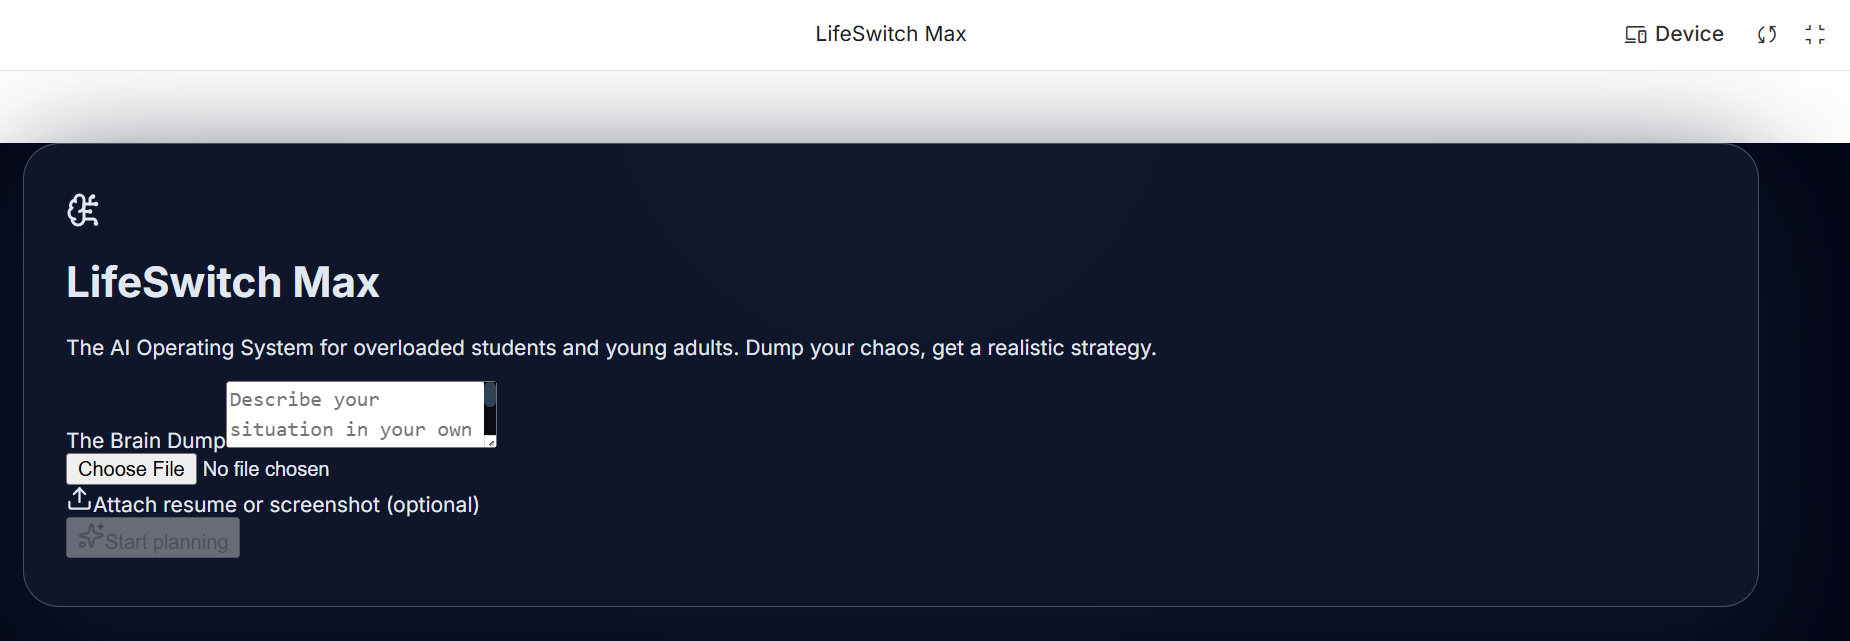
> 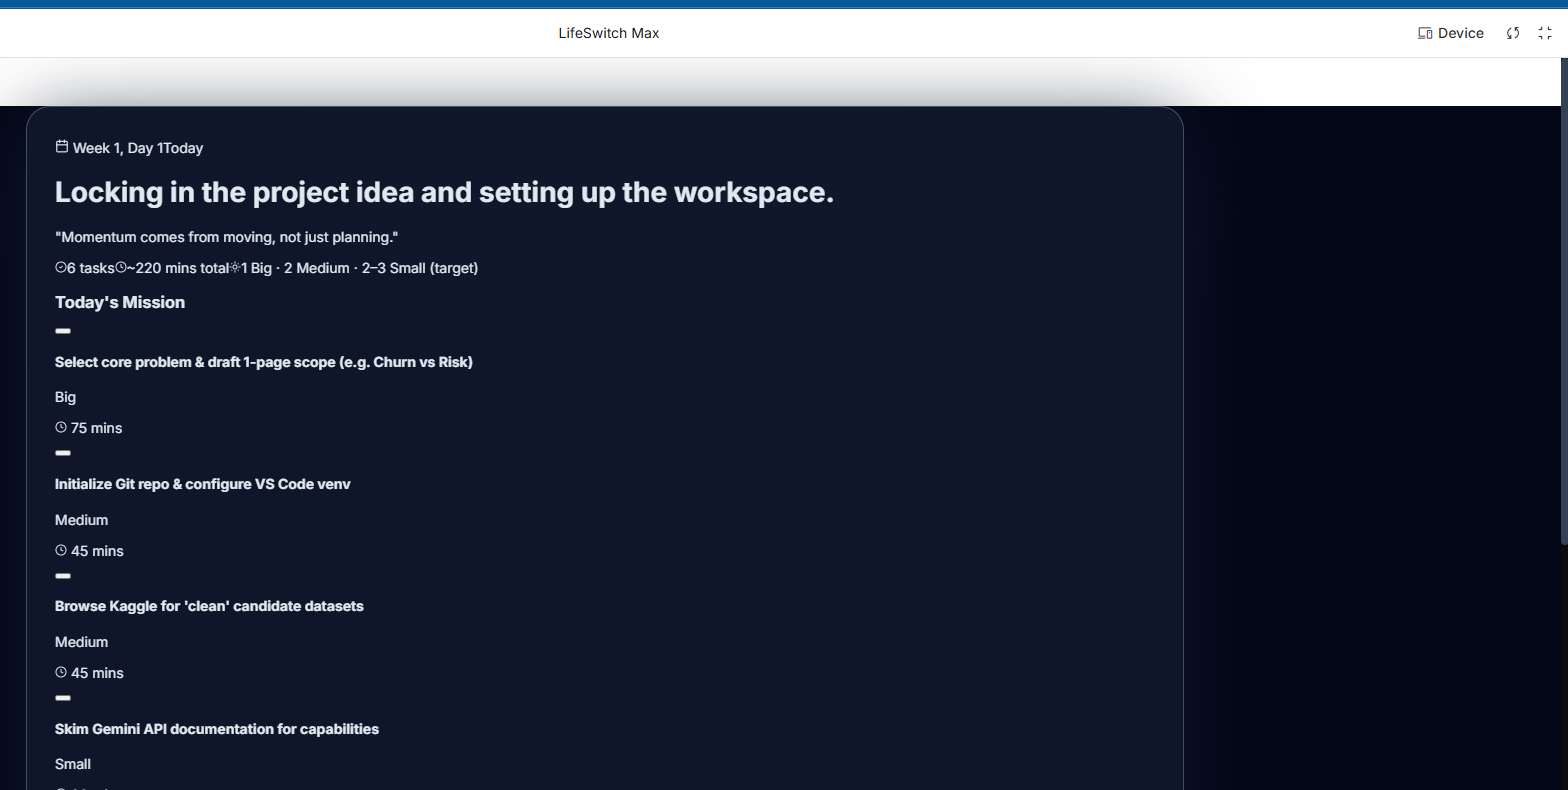

## Quick Try (copy-paste brain dump)
"I’m a final-year student with low energy, 10 hrs/week, CGPA anxiety, want a data analyst role…"

**Expected output:** LifeProfile → 3–4 paths (radar) → 12-week roadmap → today plan


## 1. Problem & Motivation

Many students and young adults are stuck in the “I know I should do *something* but my brain is fried” zone:

- Low CGPA / odd academic history → scared of job filters.
- Health / burnout / brain fog → can't follow aggressive plans.
- Too much generic advice → nothing respects their **actual** time and energy.

**Goal:** Turn one messy paragraph of their life + constraints into a *game-like dashboard* of:

- 3–4 realistic paths they can choose.
- A 12-week roadmap that fits their hours/week.
- A concrete daily plan for *today* that doesn’t cause burnout.


## 2. System Overview

LifeSwitch Max is implemented as a React + TypeScript app in Google AI Studio Code Assistant.

The pipeline has 4 Gemini stages:

1. LifeProfile extraction (Gemini 2.5 Flash, multimodal)
2. Life Path generation (Gemini 3 Pro reasoning)
3. 12-Week Roadmap planner (Gemini 3 Pro)
4. Daily Plan generator (Gemini 3 Pro)

The React frontend guides the user through:

Brain Dump screen - free text plus optional resume or screenshot upload  
Profile Review - shows the structured LifeProfile to confirm  
Path Selection - radar chart comparing feasibility, burnout and stability  
Roadmap View - 12-week timeline with themes and tasks  
Today View - one big task, two medium, two or three small tasks for today


## 3. Frontend Flow (React App)

The UI is a single-page React + TypeScript app. The main file `App.tsx` works like a state machine using an `AppStep` enum.

### 3.1 App steps

`AppStep` controls which screen the user sees:

1. `INPUT`  
   - First screen.  
   - Shows title "LifeSwitch Max", the brain dump textarea, and optional file upload.  
   - On click of "Start planning", it calls `handleAnalyze()`.

2. `ANALYZING_PROFILE`  
   - Shows a loading screen while `createLifeProfile()` talks to Gemini and returns a `LifeProfile`.

3. `PROFILE_REVIEW`  
   - Uses `<ProfileCard />` to display the structured LifeProfile.  
   - User clicks a button to confirm and trigger `handleGeneratePaths()`.

4. `GENERATING_PATHS`  
   - Loading screen while `generateLifePaths()` returns 4 paths.

5. `PATH_SELECTION`  
   - Uses `<PathCard />` in a grid.  
   - Each card shows title, description, badge and a radar chart for metrics.  
   - Clicking a card calls `handlePathSelect(path)`.

6. `GENERATING_ROADMAP`  
   - Loading screen while `generateRoadmap()` builds the 12 week plan.

7. `ROADMAP_VIEW`  
   - Uses `<RoadmapView />` to show week-by-week themes and tasks.  
   - Has a button "Generate today" that calls `handleGenerateDaily()`.

8. `DAILY_PLAN`  
   - Uses `<DailyView />` to show:  
     - focusOfTheDay  
     - motto  
     - list of tasks (Big / Medium / Small).  
   - Also has "Start a new LifeSwitch profile" which calls `handleReset()`.

### 3.2 Shared state

`App.tsx` holds all main objects in React state:

- `profile: LifeProfile | null`
- `paths: LifePath[]`
- `selectedPath: LifePath | null`
- `roadmap: RoadmapWeek[]`
- `dailyPlan: DailyPlan | null`
- `loadingMessage: string`

These states are passed down as props to the child components:

- `<ProfileCard profile={profile} ... />`
- `<PathCard path={path} ... />`
- `<RoadmapView roadmap={roadmap} ... />`
- `<DailyView plan={dailyPlan} ... />`

This keeps all Gemini calls in one place (App.tsx) and keeps the UI components mostly presentational.


## 4. Example User Journey (End-to-End)

This section shows how a real user goes from “totally stuck” to a concrete 12-week + today plan using LifeSwitch Max.

### Step 1 – Brain Dump (INPUT)

- The user lands on the **LifeSwitch Max** screen.
- They type a free-form “brain dump” about:
  - CGPA worries, gap year, health issues, family pressure, job search, entrance exams, etc.
- Optionally, they attach:
  - A **resume screenshot** or **marksheet / bank screenshot** (PDF/image) so Gemini 2.5 Flash can extract skills, dates, and constraints.
- On **“Start planning”**, the app calls `createLifeProfile()`.

### Step 2 – Structured LifeProfile (PROFILE_REVIEW)

Gemini 2.5 Flash turns the messy input into a structured JSON `LifeProfile`, including:

- `identity` → role, age estimate, basic context  
- `summary` → one-paragraph narrative of their situation  
- `stressors[]` → e.g. “health recovery”, “low CGPA filter”, “no remote job”, etc.  
- `assets.skills[]` → skills from text and resume (SQL, C++, Python, Power BI, etc.)  
- `constraints.hoursAvailablePerWeek` → approximate time user can realistically spend  
- `constraints.energyLevel` → Low / Medium / High / Variable  

The **Profile Review** screen shows this back to the user in plain language so they can see that the system “understands” their life, not just one exam.

### Step 3 – Four Life Paths (PATH_SELECTION)

`generateLifePaths()` (Gemini 3 Pro reasoning) then creates **exactly 4** distinct strategies, for example:

- **The Data Analyst Fast-Track** – focus on portfolio and SME roles  
- **Health-First Degree Completion** – stabilize health and finish degree cleanly  
- **Strategic Academic Grind** – controlled GATE / exam prep under time limits  
- **Python Freelance Pivot** – build confidence and small income via small gigs  

Each path comes with:

- A **title** and **badge** (e.g., “Recovery Mode”, “High Upside”)  
- A detailed **description** of what is prioritized vs. delayed  
- A metrics block (0–100):  
  - `feasibility`  
  - `burnoutRisk`  
  - `financialStress`  
  - `timeToStability`  
- A multi-line **reasoning** explaining trade-offs and when this path might be a bad idea.

On the UI, each path is displayed as a card. The user picks the one that feels most realistic for the next 12 weeks.

### Step 4 – 12-Week Roadmap (ROADMAP_VIEW)

For the chosen path, `generateRoadmap()` produces a **12-week plan**:

- Each week has:
  - `weekNumber`
  - `theme` (e.g., “Foundation & Audit”, “Portfolio Polish – SQL”, “Application Launch”)
  - `focus` (short description)
  - `tasks[]` = list of tasks with:
    - `name`
    - `minutes`
    - `energyType` = Focus / Drain / Recharge

The React **Roadmap View** renders this as a vertical timeline so judges can see a realistic, constraint-aware plan instead of vague advice.

### Step 5 – Today’s Plan (DAILY_PLAN)

Finally, `generateDailyPlan()` converts Week 1 into a **single realistic today schedule**:

- Exactly **1 Big** task
- **2 Medium** tasks
- **2–3 Small** tasks
- Total minutes ≤ user’s availableMinutes (e.g., 220 min instead of an impossible 10-hour list)

The **Today View** shows:

- `date`
- `focusOfTheDay`
- `motto` (short, specific to the day)
- Task list with size tags (Big / Medium / Small) and time estimates

This daily plan is still *grounded* in the chosen 12-week path and Week 1 theme, so it feels like part of a larger strategy, not random tasks.


## 5. Why LifeSwitch Max is More Than a Normal Planner

LifeSwitch Max is designed to be technically strong and non-trivial for a hackathon / research judge:

### 5.1 Multi-stage Gemini pipeline (not a single prompt)

Instead of one generic prompt, the app uses **4 clearly separated stages**, each with its own JSON schema and model choice:

1. **Multimodal profile extraction**  
   - Model: `gemini-2.5-flash`  
   - Input: long text + optional image/PDF  
   - Output: strongly typed `LifeProfile` object.

2. **Life Path generator with reasoning budget**  
   - Model: `gemini-3-pro-preview`  
   - Uses `thinkingConfig` for deeper reasoning.  
   - Enforces trade-offs between feasibility, burnout risk, financial stress, stability.

3. **12-week roadmap planner**  
   - Model: `gemini-3-pro-preview`  
   - Converts one abstract path into an operational plan with weekly themes and task-level minutes.

4. **Daily micro-planner**  
   - Model: `gemini-3-pro-preview`  
   - Applies hard numeric constraints on task counts and duration to avoid fantasy schedules.

This structure is closer to a **planning agent** than a chat bot: each stage has a clear contract, schema, and responsibility.

### 5.2 Strict JSON schemas and validation

All Gemini calls use **response schemas**:

- `LifeProfile` enforces the presence of identity, constraints, stressors, assets.
- `LifePath[]` enforces metrics, reasoning, and estimatedDurationWeeks.
- `RoadmapWeek[]` enforces energy types per task.
- `DailyPlan` enforces the “Big / Medium / Small” structure.

A small **cleanJson()** helper strips markdown code fences, so the frontend can safely `JSON.parse()` responses. This makes the system robust for live judging instead of fragile demo-only hacks.

### 5.3 Constraint-aware planning

The app does **explicit constraint handling**:

- Uses `hoursAvailablePerWeek` and `energyLevel` from the profile in `generateRoadmap()`.
- Uses `availableMinutesToday` + fixed rules (1 Big, 2 Medium, 2–3 Small) in `generateDailyPlan()`.
- Encourages realistic splits (e.g., breaking huge tasks into chunks instead of 3-hour blocks).

This is closer to **AI-assisted scheduling optimisation** than motivational quotes.

### 5.4 Multimodal extraction from screenshots / PDFs

For users who cannot type everything or are too overwhelmed:

- `createLifeProfile()` accepts an inline image/PDF as `imageBase64 + mimeType`.
- Gemini 2.5 Flash is instructed to:
  - Read skills from resume screenshots.
  - Infer financial runway from bank balance snapshots.
  - Pick up CGPA / semester status from marksheets.

This makes LifeSwitch Max more inclusive for students who only have messy, partial artifacts instead of clean data.

### 5.5 Frontend as an inspectable “AI OS”

The React app is intentionally structured so that:

- Every Gemini call is visible and inspectable inside `services/gemini.ts`.
- Every state step is visible in `App.tsx` through the `AppStep` enum.
- UI components (`ProfileCard`, `PathCard`, `RoadmapView`, `DailyView`) are focused on **explainability**:
  - You can see *why* a path was suggested.
  - You can see *what* the next 12 weeks look like.
  - You can see *exactly* what to do today.

This helps judges verify that the system is **real, reproducible, and grounded**, not just a fake front over a single prompt.


## 6. Limitations & Future Work

### 6.1 Current Limitations

- **Single-user perspective:**  
  LifeSwitch Max currently runs per user session and does not persist history across multiple days, devices, or logins. It behaves like a “session therapist” rather than a long-term coach.

- **No calendar / task integration yet:**  
  The roadmap and daily plan are generated, but they are not yet synced to Google Calendar, Notion, or any external task manager. The user has to manually transfer tasks.

- **Self-reported constraints only:**  
  Hours per week and energy levels are inferred from text and screenshots, not from real behavioral data (screen time, sleep, etc.). That can sometimes make the estimates optimistic or conservative.

- **No hard optimization backend (yet):**  
  The system uses Gemini’s reasoning + constraint-aware prompts rather than a full-blown scheduling optimizer (e.g., linear programming or reinforcement learning). For most students this is enough, but it could be more mathematically rigorous.

- **English-first experience:**  
  Although Gemini can understand many languages, the UX and prompts are currently optimized for English. A fully localized experience is future work.

### 6.2 Future Work

- **Calendar + Todo integration**  
  Push daily tasks directly into Google Calendar / Todoist / Notion, so the plan becomes instantly actionable instead of staying inside the app.

- **Real-time feedback loop**  
  Let users mark tasks as *Done / Skipped / Too hard*, and feed that back into Gemini to dynamically adjust the roadmap and daily plan for the next day.

- **Richer multimodal intake**  
  Support more document types (full transcripts, PDFs with marksheets, medical leave letters, etc.) and explicitly highlight which parts of the plan came from which artifact.

- **Multi-day “streak” mode**  
  Add a streak-based view where the user can see how many days they followed at least the Big + 1 Medium task, and adjust load if they keep missing targets.

- **Multi-user / mentor view**  
  Allow a mentor / counselor to inspect the profile, paths, and roadmap (with user consent), and co-design tweaks using Gemini as a shared assistant.


## 7. Live Demo & Links

- **Public AI Studio App (Interactive Demo)**  
  👉 [LifeSwitch Max – AI Studio App](https://ai.studio/apps/drive/1UY-wLkLrhe_eaHQoIoKtAEeTD7m7r5c5?fullscreenApplet=true)

- **Tech Stack (Frontend)**  
  - React + TypeScript UI  
  - Tailwind-style utility classes for the layout and theming  
  - Components: `ProfileCard`, `PathCard`, `RoadmapView`, `DailyView`, `LoadingScreen`

- **AI Logic (services/gemini.ts)**  
  - Stage 1: `createLifeProfile()` → Gemini 2.5 Flash multimodal profile extraction  
  - Stage 2: `generateLifePaths()` → Gemini 3 Pro reasoning (4 distinct strategies)  
  - Stage 3: `generateRoadmap()` → 12-week constraint-aware planner  
  - Stage 4: `generateDailyPlan()` → realistic Big / Medium / Small daily schedule  

This Writeup documents the architecture and behavior, while the **AI Studio app link** lets judges actually click and experience the real pipeline in action.
